A Jupyter Notebook to grab quick and easy plots of the predictions based on the prostate MRI segmentation models.

In [2]:
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from prostatemri_dataset import load_images, MRIDataset
from mriseg_models import SimpleUNet, TLDeepLabV3MobileNet

In [3]:
# Load validation dataset and create dataloader for plotting

val_images = load_images("val")

# Wrap the datasets and create dataloaders
val_dataset = MRIDataset(val_images)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [52]:
# Load the trained model

# model = SimpleUNet()
# model.load_state_dict(torch.load("prostate_unet.pth"))

model = TLDeepLabV3MobileNet(backbone_unfreeze_substrings = ("5", "6"), classifier_unfreeze_last_K = 4)
model.load_state_dict(torch.load("prostate_transfer_model.pth"))

<All keys matched successfully>

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_contours(ax, img_gray, gt_mask, pred_mask, gt_color='lime', pred_color='white', legend_flag=False):
    """ DRAWS OUTLINE OF THE GROUND TRUTH (GREEN) AND PREDICTED (WHITE) CONTOURS ON TOP OF THE GRAYSCALE IMAGE """
    
    # Display grayscale image as background
    ax.imshow(img_gray, cmap='gray', vmin=0, vmax=255)

    # Plot contours of the ground truth and predicted masks
    # Smoothing not needed; ensure masks are 0/1 floats for contouring at level=0.5
    gt_cs = ax.contour(gt_mask.astype(float), levels=[0.5], colors=gt_color, linewidths=2.0)
    pred_cs = ax.contour(pred_mask.astype(float), levels=[0.5], colors=pred_color, linewidths=2.0)

    if legend_flag:
        # Get legend handles from the contour sets
        gt_handles, _   = gt_cs.legend_elements()
        pred_handles, _ = pred_cs.legend_elements()

        # Specify handles and labels for the legend
        handles = [gt_handles[0], pred_handles[0]]
        labels  = ['Ground Truth', 'Predicted']

        # Add legend with line samples visible
        ax.legend(handles, labels, loc='upper left', frameon=True, fontsize=12)

    ax.set_axis_off()


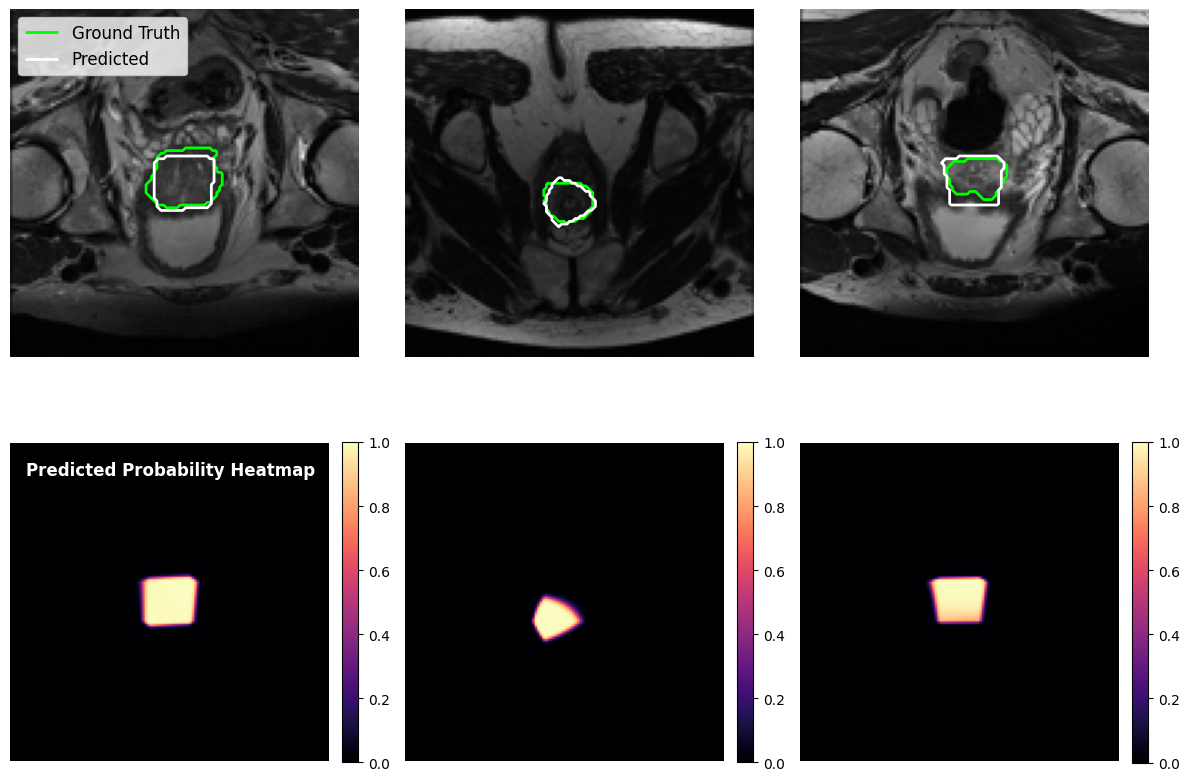

In [55]:
# Visualize predictions on validation set with contour overlays
num_samples = 3
fig, axes = plt.subplots(2, num_samples, figsize=(4 * num_samples, 9))

model.eval()
with torch.no_grad():
    for idx in range(num_samples):
        images, _ = val_dataset[idx]              # images: (1,H,W) normalized
        image_batch = images.unsqueeze(0)         # (1,1,H,W)
        outputs = model(image_batch)

        # Handle dict or tensor output
        outputs = outputs['out'] if isinstance(outputs, dict) else outputs

        # Prob -> binary
        probs = torch.sigmoid(outputs).squeeze(0).squeeze(0).cpu().numpy()  # (H, W)
        predicted_mask = (probs > 0.5).astype(np.uint8)                      # (H, W)

        # Raw image + ground truth mask from base dataset
        raw_pil, mask_pil = val_dataset.base_dataset[idx]
        raw_np  = np.array(raw_pil.convert("L"))         # (H, W) uint8
        mask_np = (np.array(mask_pil) > 0).astype(np.uint8)

        # Ground truth vs predicted contours overlaid on raw image
        overlay_contours(axes[0, idx], raw_np, mask_np, predicted_mask, legend_flag=(idx==0))

        # Probability heatmap
        im = axes[1, idx].imshow(probs, cmap='magma', vmin=0, vmax=1)
        axes[1, idx].axis('off')
        fig.colorbar(im, ax=axes[1, idx], fraction=0.046, pad=0.04)
        if idx == 0:
            axes[1, idx].text(0.05 , 0.9, 'Predicted Probability Heatmap', transform=axes[1, idx].transAxes, fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()